### Tutorial

In [7]:
from typing import Dict, List, TypedDict
import random
from langgraph.graph import StateGraph, END

In [2]:
class AgentState(TypedDict):
    name: str
    number: List[int]
    counter: int

In [3]:
def greeting_node(state: AgentState) -> AgentState:
    """Greeting Node which says hi to the person"""

    state["name"] = f'Hi there, {state["name"]}'
    state["counter"] = 0

    return state

def random_node(state: AgentState) -> AgentState:
    """Generates a random number from 0 to 10"""

    state["number"].append(random.randint(0, 10))
    state["counter"] += 1

    return state

def should_continue(state: AgentState) -> AgentState:
    """Function to decide what to do next"""

    if state["counter"] < 5:
        print("ENTERING LOOP", state["counter"])
        return "loop"    #Continue looping
    else:
        return "exit"   #Exit the loop
      

In [6]:
# Tragectory : Greet -> Random 5 times -> End

In [9]:
graph = StateGraph(AgentState)

graph.add_node("greeting", greeting_node)
graph.add_node("random", random_node)

graph.add_edge("greeting", "random")

graph.add_conditional_edges(
    "random",
    should_continue,
    {
        "loop": "random",
        "exit": END
    }
)

graph.set_entry_point("greeting")

app = graph.compile()

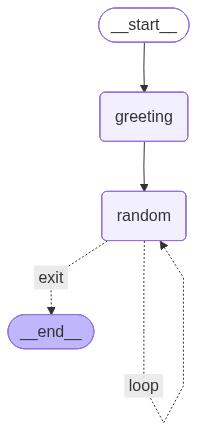

In [10]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [12]:
result = app.invoke({"name": "Ashutosh", "number": [], "counter": 0})
print(result)

ENTERING LOOP 1
ENTERING LOOP 2
ENTERING LOOP 3
ENTERING LOOP 4
{'name': 'Hi there, Ashutosh', 'number': [5, 4, 2, 0, 4], 'counter': 5}


### My Turn

In [7]:
from typing import List, Dict, TypedDict
from langgraph.graph import StateGraph, END
import random

In [2]:
class AgentState(TypedDict):
    player_name: str
    guesses: List[int]
    attempts: int
    lower_bound: int
    upper_bound: int
    my_number: int
    guess_number: int
    response: str

In [3]:
def setup_node(state: AgentState) -> AgentState:
    """ I am settig up the values of attempts"""

    state["attempts"] = 0
    state["response"] = "NILL"

    return state

def guessing_node(state: AgentState) -> AgentState:
    state["guess_number"] = random.randint(state["lower_bound"], state["upper_bound"])

    state["guesses"].append(state["guess_number"])
    state["attempts"] += 1

    return state

def hint_node(state: AgentState) -> AgentState:
    
    if state["guess_number"] < state["my_number"]:
        state["response"] = "HIGHER"
        state["lower_bound"] = state["guess_number"] + 1
    else:
        state["response"] = "LOWER"
        state["upper_bound"] = state["guess_number"] - 1
    
    return state

def check_guess_status(state: AgentState) -> str:
    """This only routes the graph. It does not change the state"""

    if state["guess_number"] == state["my_number"]:
        print("You found the number!")
        return "exit"
    elif state["attempts"] >= 7:
        print("Couldn't find the number within 7 attempts, exiting.")
        return "exit"
    else:
        print("Entering Loop", state["attempts"])
        return "loop"

In [4]:
graph = StateGraph(AgentState)

graph.add_node("setup", setup_node)
graph.add_node("guess", guessing_node)
graph.add_node("hint_node", hint_node)

graph.add_edge("setup", "guess")


graph.add_conditional_edges(
    "guess",
    check_guess_status,
    {
        "loop": "hint_node",
        "exit": END
    }

)

graph.add_edge("hint_node", "guess")

graph.set_entry_point("setup")

app = graph.compile()

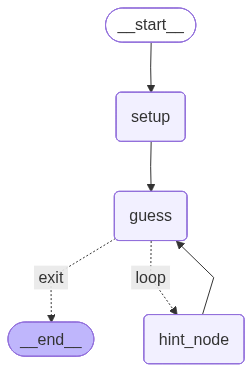

In [5]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [8]:
result = app.invoke({"player_name": "Ashutosh", "guesses": [], "attempts": -10, "lower_bound": 0, "upper_bound": 20, "my_number": 6})
print(result)


Entering Loop 1
Entering Loop 2
Entering Loop 3
You found the number!
{'player_name': 'Ashutosh', 'guesses': [14, 2, 10, 6], 'attempts': 4, 'lower_bound': 3, 'upper_bound': 9, 'my_number': 6, 'guess_number': 6, 'response': 'LOWER'}
